In [1]:
%matplotlib widget
import scipp as sc
import plopp as pp
import scippneutron as scn
import scippnexus as snx
import h5py
from pathlib import Path
import numpy as np

## An simulated sample with incoherent elastic scattering and one phonon mode
The data file specified below contains simulated scattering from a sample with one incoherent elastic scattering mode,
and one phonon mode with instrument-parameter controlled slope, `sound_speed`.

A standard-McStas particle can only scatter from either the elastic mode _or_ phonon,
and this simulation splits the particles equally between the two modes.
A better approach would have been sending significantly more particles to the phonon.

The phonon FCC lattice constant $a=6.56162$ Å was chosen such that its {200} Bragg peaks (not simulated) 
would appear at 90 degree $a_4$ in the $E_f = 3.8$ meV analyzers.

The simulation was conducted as an sample orientation scan with all other parameters fixed.

| Parameter | Value | Notes |
|-----------|-------|-------|
| `sound_speed` / meV Å | 2.5 |  |
| $a_3$ / degree | 0:179 | 1-degree steps, endpoints included |
| $a_4$ / degree | 90. | all simulations have this single detector tank position |
| pulse-shaping chopper opening time  / msec | 0.2 | picked to be a realistic best-case energy-resolution |
| minimum $E_i$ / meV | 2.5 | giving a maximum of ~5.1 meV due to BIFROST's pseudo-white beam |

The simulation was started at approxmately 5:37 UTC on 14. September 2024, 
and required approximately 30 seconds per $a_3$ setting using MPI with 6 nodes.

In [2]:
datafile = "20240914/BIFROST_20240914T053723.h5"

In [3]:
from bifrost2409.config import POOCH_DATA_DIR, INTERIM_DATA_DIR
from bifrost2409.dataset import download_datafiles
download_datafiles([datafile])

2024-11-25 11:03:29.479 | INFO     | bifrost2409.config:<module>:13 - PROJ_ROOT path is: /home/g/Projects/20240914/bifrost-workflow-2409
Fetching: 100%|█████████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.47it/s]


### Trust the workflow, use the worflow

Now that we trust the process that we performed 'by hand' in the last two notebooks,
we can make use of the same process available through the workflow in abbreviated form
as `bifrost_single`, which _ignores_ any scan information and treats all data as a single setting.

> **Note**: Since the workflow is _intended_ for _real_ data, but our simulations need some manipulations
> you _must_ specify that this datafile `is_simulated`.

In [4]:
from ess.spectroscopy.indirect import bifrost_single
as_one = bifrost_single(POOCH_DATA_DIR / datafile, is_simulated=True)

We can get an overview of the per-pixel inelastic spectrum (but we plot it here as a function of 10% of a _tube_)

In [5]:
tube_count = 3 * 9 * 5 * 10
as_one['events'].bin(energy_transfer=100).hist(
    energy_transfer=sc.linspace(start=-1.7, stop=1.7, num=50, dim='energy_transfer', unit='meV'),
    detector_number=tube_count,
).plot(norm='log')

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

/home/g/Projects/20240914/bifrost-workflow-2409/new_venv/lib/python3.11/site-packages/plopp/backends/matplotlib/canvas.py:140: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


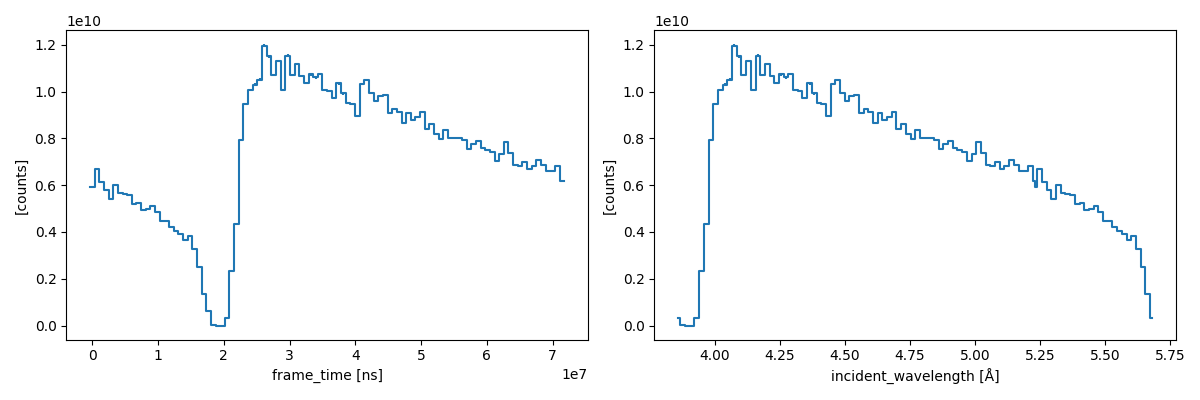

In [6]:
as_one['norm_monitor'].plot() + as_one['wavelength_monitor'].plot()

Converting this data to S(**Q**, E) requires splitting the continuous measurement-time dimension of the data into discrete 
periods with constant settings.
> **Note**: currently, this can be done _exactly_ since the `NXlog` values of simulated parameters are stable and precise.
> The same should be true in most cases for parameter _set points_, so they will be used to segment real data.
>

A different workflow entry-point `bifrost` segments the data (currently limited to constant ($a_3$, $a_4$) pairs),
then calls, effectively, `bifrost_single` per segment before calculating **Q** _in the sample table coordinate system_ 
and combining the data.

_This process is unoptimized and slow -- about 15 minutes on my laptop, so we will store the result to avoid re-creating it unnecessarily_

In [7]:
from ess.spectroscopy.indirect import bifrost

In [8]:
# import cProfile
# import pstats
# from pstats import SortKey

# cProfile.run('data = bifrost(POOCH_DATA_DIR / datafile, is_simulated=True)', 'cstats')
# p = pstats.Stats('cstats')

# print(snx.__version__)

# p.sort_stats(SortKey.CUMULATIVE).print_stats(10)


In [9]:
targets = [
    'triplet_events',
    'norm_monitor',
    'events',
    'sample_detector_flight_time',
    'analyzers',
    'wavelength_monitor',
    'norm_events',
]
target_files = {target: INTERIM_DATA_DIR / f'{Path(datafile).stem}_{target}.h5' for target in targets}
if all(file.exists() for file in target_files.values()):
    from scipp.io import load_hdf5
    objects = {target: load_hdf5(file) for target, file in target_files.items()}
else:
    data = bifrost(POOCH_DATA_DIR / datafile, is_simulated=True)
    objects = {target: data[target] for target in targets}
    for target in targets:
        objects[target].save_hdf5(target_files[target])


In [10]:
events = objects['events']

In [11]:
def hQ(events, energy_transfer_range, q_bins, coords = None, event_coords = None):
    if coords is None:
        coords = ('a3', 'a4', 'detector_number', 'energy_transfer', 'final_energy')
    if event_coords is None:
        event_coords = ('event_time_offset', 'event_time_zero', 'frame_time', 'incident_energy', 'lab_momentum_x', 'lab_momentum_z')
    x = events.bin(energy_transfer=energy_transfer_range)
    for coord in coords:
        del x.coords[coord]
    for coord in event_coords:
        del x.bins.coords[coord]
    for dim in ('setting', 'detector_number'):
        x = x.bins.concat(dim)
    return x.squeeze().bin(table_momentum_x=q_bins, table_momentum_z=q_bins)


In [12]:
def hQ2(events, energy_transfer_range, q_bins, keep=None):
    minimal_keep = {'table_momentum_x', 'table_momentum_z', 'arc'}
    if keep is None:
        keep = minimal_keep
    else:
        keep = set(keep) + set(minimal_keep)
    binned = events.bin(energy_transfer=energy_transfer_range)
    drop = [x for x in list(binned.coords) if x not in keep]
    binned.drop_coords(drop)
    for dim in [d for d in binned.dims if d not in keep]:
        binned = binned.bins.concat(dim)
    return binned.squeeze().bin(table_momentum_x=q_bins, table_momentum_z=q_bins).hist()

In [13]:
%time hQ2(events, sc.array(values=[-0.05, 0.05], dims=['energy_transfer'], unit='meV'), 200).plot(norm='log')

CPU times: user 5.65 s, sys: 3.26 s, total: 8.91 s
Wall time: 2.64 s


InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [14]:
from ess.bifrost.detector import arc_number
with_arc = events.transform_coords(arc=arc_number)
# hQ(with_arc.group('arc'), sc.array(values=[-0.05, 0.05], dims=['energy_transfer'], unit='meV'), 200)
with_arc

<scipp.DataArray>
Dimensions: Sizes[setting:180, detector_number:13500, ]
Coordinates:
* a3                        float32            [deg]  (setting)  [0, 1, ..., 178, 179]
* a4                        float32            [deg]  ()  90
* arc                         int64  [dimensionless]  (detector_number)  [0, 0, ..., 4, 4]
* detector_number             int64        <no unit>  (detector_number)  [1, 2, ..., 13499, 13500]
  final_energy              float64            [meV]  (detector_number)  [2.68475, 2.68449, ..., 5.06818, 5.06863]
* theta                     float64            [deg]  (detector_number)  [47.262, 47.3189, ..., 132.732, 132.787]
Data:
                          DataArrayView        <no unit>  (setting, detector_number)  binned data: dim='event', content=DataArray(
          dims=(event: 11545264),
          data=float32[counts],
          coords={'event_time_offset':int32[ns], 'event_time_zero':datetime64[ns],
                  'frame_time':float64[ns], 'energy_transfer':float64[meV],
                  'incident_energy':float64[meV], 'lab_momentum_x':float64[1/Å],
                  'lab_momentum_z':float64[1/Å], 'table_momentum_x':float64[1/Å],
                  'table_momentum_z':float64[1/Å], 'incident_wavelength':float64[Å]})

In [15]:
hQ(events, sc.array(values=[0.3, 0.9], dims=['energy_transfer'], unit='meV'), 200).hist().plot(norm='log')

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [16]:
hQ(events, sc.array(values=[1., 1.6], dims=['energy_transfer'], unit='meV'), 200).hist().plot(norm='log')

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [17]:
def hist_E_plane(events, q_x_range, q_bins, e_bins):
    a = events.bin(table_momentum_x=q_x_range)
    # Remove coordinates and event coordinates that we're not using:
    for coord in ('a3', 'a4', 'detector_number', 'final_energy'):
        if coord in a.coords:
            del a.coords[coord]
    for coord in ('event_time_offset', 'event_time_zero', 'frame_time', 'incident_energy', 'lab_momentum_x', 'lab_momentum_z'):
        if coord in a.bins.coords:
            del a.bins.coords[coord]
    # drop the non-energy_transfer dimensions before binning in Q
    for dim in ('setting', 'detector_number'):
        if dim in a.dims:
            a = a.bins.concat(dim)
    return a.bin(energy_transfer=e_bins, table_momentum_z=q_bins).hist()['table_momentum_x', 0]
 

In [18]:
astar = 2 * np.pi / 6.56162

In [19]:
hist_E_plane(events, sc.array(values=[2 * astar - 0.2,  2 * astar + 0.2], dims=['table_momentum_x'], unit='1/angstrom'), 200, 50).plot(norm='log')

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [20]:
def arc_plots(fun, data, *args, **kwargs):
    from ipywidgets import VBox, HBox
    slices = fun(data.group('arc'), *args)
    to_plot = {f'arc_{n}': slices['arc', n] for n in range(slices.sizes['arc'])}
    to_plot['all'] = fun(data, *args)
    ps = [pp.plot(v, title=k, **kwargs) for k, v in to_plot.items()]
    return VBox([HBox(ps[:3]), HBox(ps[3:])])

In [21]:
arc_plots(hQ2, with_arc, sc.array(values=[-0.05, 0.05], dims=['energy_transfer'], unit='meV'), 200, figsize=(4,3), norm='log')

In [22]:
dx = 0.1
x_range = sc.array(values=[2*astar-dx, 2*astar+dx], dims=['table_momentum_x'], unit='1/angstrom')
n_en, n_z = 100, 200

arc_plots(hist_E_plane, with_arc, x_range, n_z, n_en, figsize=(4,3), norm='log', vmax=3)

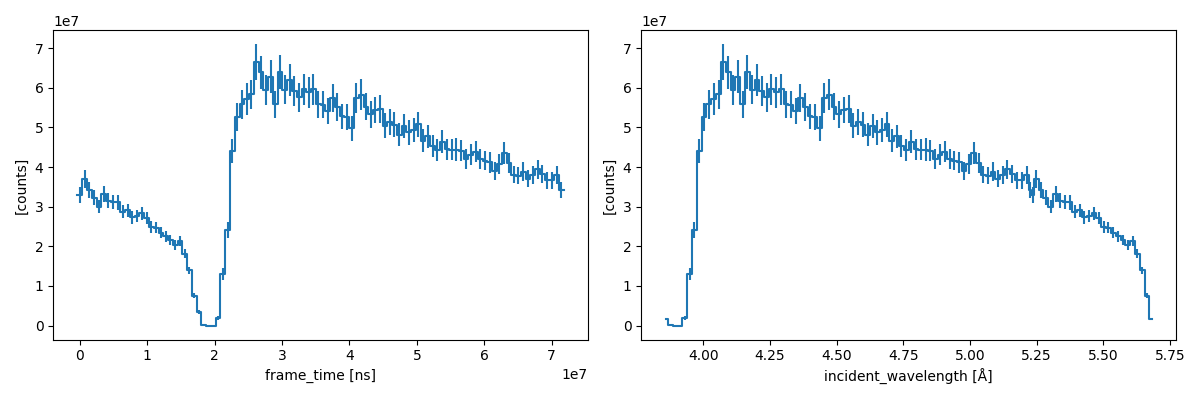

In [23]:
nmon = objects['norm_monitor']['setting',0]
wmon = objects['wavelength_monitor']['setting',0]
nmon.plot() + wmon.plot()